# PRIME analysis of the BRCA dataset
This notebook demonstrates the complete analysis workflow used to apply PRIME to the BRCA1-null single-cell RNA-seq dataset. The workflow consists of four main steps:

1. **Data preparation:** load spliced and unspliced expression matrices and select highly variable genes (HVGs).
2. **Cell clustering:** apply PRIME clustering to jointly analyze the spliced and unspliced expression measurements.
3. **Bayesian parameter inference:** infer gene-level kinetic parameters for each cluster.
4. **Differential analysis:** compare inferred parameters between clusters and identify genes with significant differences in burst size, burst frequency, and the splicing-related parameter $\tau$.

The notebook is intended to be reproducible and can also be adapted to other datasets by changing the input file paths and clustering parameters.

In [1]:
using Pkg
Pkg.activate(".")
# using Prime

  Activating new project at `~/Desktop/Prime-2/run_prime`


### Parallel computation
PRIME clustering and downstream inference can use multiple Julia worker processes. The number of workers can be adjusted according to the available CPU resources. In the example below, four additional worker processes are used.

In [2]:
using Distributed
addprocs(4)
@everywhere using Prime

## Input data
The input expression data are provided in loom format and contain two expression layers:
- `layers/spliced`: spliced RNA count matrix.
- `layers/unspliced`: unspliced RNA count matrix.
The expression matrices are organized as **cells × genes**.
Before running the PRIME clustering analysis, highly variable genes (HVGs) must first be selected using the preprocessing script: Preprocess_data.py

In [ ]:
using HDF5,DelimitedFiles,StatsBase
# Spliced/unspliced expression matrix and gene names
f = h5open("dataset/analysis/processed_brca1_raw.loom", "r")
# HVG selection mask
mask_raw = readdlm("dataset/analysis/brca_filtered_highly_variable.csv", ',')[2:end, 2]
mask = map(x -> x == "True", mask_raw)
print("Hvgs for brca clustering ",sum(mask))

Hvgs for brca clustering 266

In [ ]:
# Apply the same HVG mask to both unspliced and spliced matrices
println(">>> read spliced / unspliced / gene names ...")
rdm_full = read(f["layers/spliced"])
rdn_full = read(f["layers/unspliced"])
gene_names = read(f["row_attrs/gene_name"])

rdm = rdm_full[:, mask];
rdn = rdn_full[:, mask];
gene_name_hvg = gene_names[mask];

>>> read spliced / unspliced / gene names ...


### Cell-specific scaling factor
We then define the cell-specific scaling factor
$$
\beta_i =
\frac{x_i}{\frac{1}{N}\sum_{j=1}^{N}x_j}.
$$
This scaling factor is supplied to PRIME during clustering and downstream inference.

In [5]:
X_all = rdm_full + rdn_full
total_rd = sum(X_all, dims=2)             
β = vec(total_rd ./ mean(total_rd))       
n, p = size(rdn)

k = 5
sel = 4

4

## PRIME cell clustering
We next perform cell clustering using PRIME based on the spliced and unspliced expression matrices.
The main parameters are:
- `k = 5`: the number of cell clusters specified for this analysis.
- `sel = 4`: the PRIME selection model used in the reported analysis.
- `maxiter = 20`: the maximum number of iterations used by the clustering procedure (default settings).

The function returns:
- `cluster_labels`: the inferred hard cluster assignment for each cell.
- `γ`: the soft cluster assignment for each cell (cell*k).

The resulting cell labels are subsequently used to define cell populations for gene-level parameter inference and differential analysis.

In [6]:
cluster_labels, γ = Prime.prime_cluster(
    rdn, rdm, β, k;
    sel = sel,
    maxiter = 20,  
)

cluster_labels

┌ Info: PRIME iter 1, obj = 5.838042227108134
└ @ Prime /Users/daniel/.julia/dev/Prime/src/cluster.jl:120
┌ Info: PRIME iter 2, obj = 5.813201302436969
└ @ Prime /Users/daniel/.julia/dev/Prime/src/cluster.jl:120
┌ Info: PRIME iter 3, obj = 5.80629041803761
└ @ Prime /Users/daniel/.julia/dev/Prime/src/cluster.jl:120
┌ Info: PRIME iter 4, obj = 5.799244760073625
└ @ Prime /Users/daniel/.julia/dev/Prime/src/cluster.jl:120
┌ Info: PRIME iter 5, obj = 5.773871296201184
└ @ Prime /Users/daniel/.julia/dev/Prime/src/cluster.jl:120
┌ Info: PRIME iter 6, obj = 5.700056093802159
└ @ Prime /Users/daniel/.julia/dev/Prime/src/cluster.jl:120
┌ Info: PRIME iter 7, obj = 5.327043673232436
└ @ Prime /Users/daniel/.julia/dev/Prime/src/cluster.jl:120
┌ Info: PRIME iter 8, obj = 4.627740214238804
└ @ Prime /Users/daniel/.julia/dev/Prime/src/cluster.jl:120
┌ Info: PRIME iter 9, obj = 4.316308179990958
└ @ Prime /Users/daniel/.julia/dev/Prime/src/cluster.jl:120
┌ Info: PRIME iter 10, obj = 4.142865209552964


2810-element Vector{Int64}:
 5
 4
 3
 3
 3
 1
 3
 1
 3
 4
 ⋮
 2
 1
 4
 1
 1
 1
 3
 1
 5

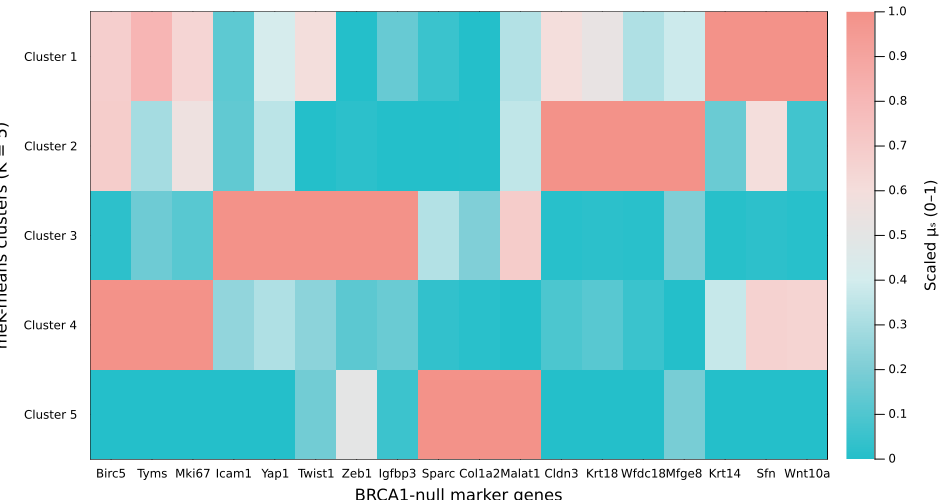

In [11]:
#############literature marker gene fig5b
#using Plots,ColorSchemes
using Plots
K = unique(cluster_labels)
#Calculate average expression per cluster
avg_expr = zeros(length(K), size(rdm_full, 2))
for k in 1:length(K)
    idx = findall(cluster_labels .== K[k])
    if !isempty(idx)
        avg_expr[k, :] = vec(mean((rdm_full+rdn_full)[idx, :], dims=1))
    end
end

markers = [
    "Birc5","Tyms","Mki67",

    "Icam1","Yap1","Twist1","Zeb1","Igfbp3",

    "Sparc","Col1a2","Malat1",

    "Cldn3","Krt18","Wfdc18","Mfge8",

    "Krt14","Sfn","Wnt10a"
]

# Find indices of marker genes in gene_names
marker_idx = [findfirst(==(m), gene_names) for m in markers if m in gene_names]
selected_markers = gene_names[marker_idx]

# Get average expression of marker genes
avg_marker_expr = avg_expr[:, marker_idx]
# Min-max normalization
function minmax_normalize(mat)
    normed = similar(mat)
    for j in 1:size(mat, 2)
        col = mat[:, j]
        minv, maxv = minimum(col), maximum(col)
        if maxv == minv
            normed[:, j] .= 0.0
        else
            normed[:, j] .= (col .- minv) ./ (maxv - minv)
        end
    end
    return normed
end
scaled_expr = minmax_normalize(avg_marker_expr)

palA = cgrad(["#24BFCA","#7ECED6","#D4EDEE","#F4DEDC","#F7B8B7","#F39289"],256);
K = length(unique(cluster_labels))

heatmap(
    scaled_expr,
    color = palA,                    
    yflip = true,
    xticks = (1:length(selected_markers), selected_markers),
    yticks = (1:K, ["Cluster $i" for i in 1:K]),
    xlabel = "BRCA1-null marker genes",
    ylabel = "meK-means clusters (K = $K)",
    colorbar_title = "Scaled μₛ (0–1)",
    framestyle = :box,
    size = (950, 500)
)

## Gene-level Bayesian parameter inference
After obtaining the cell clusters, we perform gene-level Bayesian inference separately for the genes that satisfy the expression filtering criterion.

For each gene, cells with insufficient expression across the dataset are excluded from the inference step. In the current implementation, a gene is retained if it is nonzero in more than three cells.

PRIME inference is then performed using the inferred cell clusters and the cell-specific scaling factors $\beta$.

The function prime_infer_to_csv performs gene-wise Bayesian inference using the filtered unspliced and spliced count matrices, the cell-specific scaling factors $\beta$, and the inferred cluster labels. The posterior samples and summary statistics are written to outfile, which is subsequently used for differential analysis between clusters.

In [13]:
Xa = rdm_full+rdn_full
cell_counts = [count(!iszero, Xa[:,i]) for i in 1:size(Xa, 2)]
expr_mask = cell_counts .> 3
print("Inference gene number ",sum(expr_mask))

rdm_inf = read(f["layers/spliced"])[:,expr_mask];
rdn_inf = read(f["layers/unspliced"])[:,expr_mask];
gene_inf = gene_names[expr_mask];

Inference gene number 18730

In [ ]:
#Use prime_infer_to_csv function to do bayesian inference 
# outfile = "brca_posterior.csv"
# prime_infer_to_csv(rdm_inf,rdn_inf,β,cluster_labels,gene_inf,outfile)

In [30]:
using CSV,DataFrames
function relabel_each_gene_vector(rdm, rdn,
                                  cluster_labels;
                                  nsigma::Real=5.0)
    n_cells, n_genes = size(rdm)
    n_clusters = maximum(cluster_labels)
    gene_cluster_labels = Vector{Vector{Int}}(undef, n_genes)

    for g in 1:n_genes
        new_label = zeros(Int, n_cells)  # 当前基因的细胞标签
        for c in 1:n_clusters
            idx = findall(==(c), cluster_labels)
            if isempty(idx)
                continue
            end

            μm, σm = mean(rdm[idx, g]), std(rdm[idx, g])
            μn, σn = mean(rdn[idx, g]), std(rdn[idx, g])

            for i in idx
                in_m = (rdm[i, g] >= μm - nsigma*σm) && (rdm[i, g] <= μm + nsigma*σm)
                in_n = (rdn[i, g] >= μn - nsigma*σn) && (rdn[i, g] <= μn + nsigma*σn)
                if in_m && in_n
                    new_label[i] = c
                else
                    new_label[i] = 0
                end
            end
        end
        gene_cluster_labels[g] = new_label
    end
    total_zero = [count(==(0), lbl) for lbl in gene_cluster_labels]

    return gene_cluster_labels
end


function parse_post(s)
    isempty(s) && return Float64[]
    parse.(Float64, filter(!isempty, split(s, ';')))
end

function slice_by_class(df::DataFrame, cls::Int)
    return df[df.class .== cls, [:gene,
        :bs, :bf,
        :bs_posterior, :bf_posterior, :tau_posterior,
        :bs_ess, :bf_ess, :tau_ess,
        :bs_ci, :bf_ci, :tau_ci,
        :rho_med, :sigma_on_med, :sigma_off_med, :tau_med
    ]]
end

function p_two_sided_exact(xa::AbstractVector{<:Real}; xb::AbstractVector{<:Real},
                           floor_val::Float64=1e-6)
    if isempty(xa) || isempty(xb)
        return 1.0
    end
    xa_log = log.(max.(xa, floor_val))
    xb_log = log.(max.(xb, floor_val))

    xb_sorted = sort(xb_log)                
    m = length(xb_sorted)

    total_pairs = length(xa_log) * m
    total_score = 0.0                       

    @inbounds for v in xa_log
        lo = searchsortedfirst(xb_sorted, v) 
        hi = searchsortedlast(xb_sorted, v)  
        less  = lo - 1
        equal = hi - lo + 1
        total_score += less + 0.5*max(equal, 0)
    end

    p_sup = total_score / total_pairs
    p_two = 2 * min(p_sup, 1 - p_sup)
    return clamp(p_two, 0.0, 1.0)
end

function bh_qvalues(p::AbstractVector{<:Real}) 
    n = length(p)
    idx = sortperm(p)             
    q   = similar(p, Float64)
    minq = 1.0
    for k in reverse(1:n)         
        i = idx[k]
        minq = min(minq, p[i]*n/k)
        q[i] = minq
    end
    clamp.(q, 0.0, 1.0)
end

function diff_markers(df::DataFrame, cls_a::Int, cls_b::Int,
    rdm::AbstractMatrix, rdn::AbstractMatrix, cluster_labels, gene_names,
    thrpars::Float64=1.0,      
    s_fc_thr::Float64=1.0,     
    thrmean::Float64=1., 
    p_thr :: Float64 = 0.05,
    param_thr :: Float64 = 1.5,
    eps::Float64=1e-12)

    A = slice_by_class(df, cls_a)
    B = slice_by_class(df, cls_b)
    common = intersect(A.gene, B.gene)
    A = A[in.(A.gene, Ref(common)), :]
    B = B[in.(B.gene, Ref(common)), :]

    cnt = countmap(gene_names)
    keep_genes = [g for g in gene_names if cnt[g] == 1]
    keep_idx = findall(g -> cnt[g] == 1, gene_names)

    @assert keep_genes == gene_names[keep_idx]

    A = A[A.gene .∈ Ref(keep_genes), :]
    B = B[B.gene .∈ Ref(keep_genes), :]

    gene_order = Dict(g => i for (i, g) in enumerate(keep_genes))
    A = A[sortperm(A.gene, by = g -> gene_order[g]), :]
    B = B[sortperm(B.gene, by = g -> gene_order[g]), :]

   rename!(A, Dict(
        :bs => :bs_a, :bf => :bf_a,
        :bs_posterior => :bs_post_a, :bf_posterior => :bf_post_a, :tau_posterior => :τ_post_a,
        :bs_ess => :bs_ess_a, :bf_ess => :bf_ess_a, :tau_ess => :τ_ess_a,
        :rho_med => :ρ_a, :sigma_on_med => :σon_a, :sigma_off_med => :σoff_a, :tau_med => :τ_a,
        :bs_ci => :bs_ci_a, :bf_ci => :bf_ci_a, :tau_ci => :tau_ci_a
    ))
    rename!(B, Dict(
        :bs => :bs_b, :bf => :bf_b,
        :bs_posterior => :bs_post_b, :bf_posterior => :bf_post_b, :tau_posterior => :τ_post_b,
        :bs_ess => :bs_ess_b, :bf_ess => :bf_ess_b, :tau_ess => :τ_ess_b,
        :rho_med => :ρ_b, :sigma_on_med => :σon_b, :sigma_off_med => :σoff_b, :tau_med => :τ_b,
        :bs_ci => :bs_ci_b, :bf_ci => :bf_ci_b, :tau_ci => :tau_ci_b
    ))
    M = innerjoin(A, B, on=:gene)  
    nG = nrow(M)
    print(all(A.gene .== keep_genes .== B.gene))

    log2FC_bs = log2.((M.bs_a .+ eps) ./ (M.bs_b .+ eps))
    log2FC_bf = log2.((M.bf_a .+ eps) ./ (M.bf_b .+ eps))
    log2FC_τ = log2.((M.τ_a .+ eps) ./ (M.τ_b .+ eps))

    p_bs      = Vector{Float64}(undef, nG)
    p_bf      = Vector{Float64}(undef, nG)
    p_τ      = Vector{Float64}(undef, nG)
    param_bs_ok = falses(nG)  
    param_bf_ok = falses(nG)  
    param_splicing_ok = falses(nG) 
    
    @inbounds for i in 1:nG
        xa_bs = parse_post(M.bs_post_a[i]); xb_bs = parse_post(M.bs_post_b[i])
        xa_bf = parse_post(M.bf_post_a[i]); xb_bf = parse_post(M.bf_post_b[i])
        xa_τ = parse_post(M.τ_post_a[i]); xb_τ = parse_post(M.τ_post_b[i])
        p_bs[i] = p_two_sided_exact(xa_bs; xb=xb_bs)  
        p_bf[i] = p_two_sided_exact(xa_bf; xb=xb_bf)  
        p_τ[i] = p_two_sided_exact(xa_τ; xb=xb_τ)  

        bs_ci_a = parse.(Float64, split(M.bs_ci_a[i], ",")); bs_ci_b = parse.(Float64, split(M.bs_ci_b[i], ","))
        bf_ci_a = parse.(Float64, split(M.bf_ci_a[i], ",")); bf_ci_b = parse.(Float64, split(M.bf_ci_b[i], ","))
        tau_ci_a = parse.(Float64, split(M.tau_ci_a[i], ",")); tau_ci_b = parse.(Float64, split(M.tau_ci_b[i], ","))
        bs_ratio_a = abs(bs_ci_a[2] - bs_ci_a[1]) / (median(xa_bs) + eps); bs_ratio_b = abs(bs_ci_b[2] - bs_ci_b[1]) / (median(xb_bs) + eps)
        bf_ratio_a = abs(bf_ci_a[2] - bf_ci_a[1]) / (median(xa_bf) + eps); bf_ratio_b = abs(bf_ci_b[2] - bf_ci_b[1]) / (median(xb_bf) + eps)
        tau_ratio_a = abs(tau_ci_a[2] - tau_ci_a[1]) / (median(xa_τ) + eps); tau_ratio_b = abs(tau_ci_b[2] - tau_ci_b[1]) / (median(xa_τ) + eps)
        param_bs_ok[i] = all([bs_ratio_a,bs_ratio_b].<param_thr) || all([abs(bs_ci_a[2] - bs_ci_a[1]),abs(bs_ci_b[2] - bs_ci_b[1])].<0.1)
        param_bf_ok[i] = all([bf_ratio_a,bf_ratio_b].<param_thr) || all([abs(bf_ci_a[2] - bf_ci_a[1]),abs(bf_ci_b[2] - bf_ci_b[1])].<0.1)
        param_splicing_ok[i] = all([tau_ratio_a,tau_ratio_b].<param_thr) || all([abs(tau_ci_a[2] - tau_ci_a[1]),abs(tau_ci_b[2] - tau_ci_b[1])].<0.1)
    end
    p_bs = bh_qvalues(p_bs)
    p_bf = bh_qvalues(p_bf)
    p_τ = bh_qvalues(p_τ)

    mean_ok   = falses(nG)
    log2FC_S  = zeros(nG)
    p_ok_count = falses(nG)
    param_ok = falses(nG)  

    X = rdm+rdn
    cell_total = sum(X, dims=2)
    X_norm = X ./ max.(cell_total, eps) .* 1e4
    X_log  = log1p.(X_norm)
    X = X_log
    for i in 1:nG
        cells_a = findall(==(cls_a), cluster_labels[keep_idx[i]]); cells_b = findall(==(cls_b), cluster_labels[keep_idx[i]])
        @assert !isempty(cells_a) && !isempty(cells_b) "cls_a/cls_b is empty."
        meanm_a_all = mean(rdm[cells_a, keep_idx[i]]); 
        meanm_b_all = mean(rdm[cells_b, keep_idx[i]]); 
        meann_a_all = mean(rdn[cells_a, keep_idx[i]]);
        meann_b_all = mean(rdn[cells_b, keep_idx[i]]); 
        p_ok_count[i] = (pvalue(MannWhitneyUTest(X[cells_a,keep_idx[i]], X[cells_b,keep_idx[i]])) < 0.05) 
        mean_ok[i]  = ((meann_a_all > thrmean) || (meann_b_all > thrmean)) ||  ((meanm_a_all > thrmean) || (meanm_b_all > thrmean))
        log2FC_S[i] = log2(expm1((mean(X[cells_a, keep_idx[i]])) + eps) / expm1((mean(X[cells_b, keep_idx[i]])) + eps))
    end

    ess_ok_bs = (M.bs_ess_a .>= 100.0) .& (M.bs_ess_b .>= 100.0)
    ess_ok_bf = (M.bf_ess_a .>= 100.0) .& (M.bf_ess_b .>= 100.0)
    ess_ok_τ = (M.τ_ess_a .>= 100.0) .& (M.τ_ess_b .>= 100.0)

    p_ok_bs   = p_bs .< p_thr
    p_ok_bf   = p_bf .< p_thr
    p_ok_τ   = p_τ .< p_thr

    deTheta_FC_bs    = (abs.(log2FC_bs) .> thrpars) .& mean_ok .& ess_ok_bs .& p_ok_bs  .& param_bs_ok
    deTheta_FC_bf    = (abs.(log2FC_bf) .> thrpars) .& mean_ok .& ess_ok_bf .& p_ok_bf  .& param_bf_ok
    deTheta_FC_τ    = (abs.(log2FC_τ) .> thrpars) .& mean_ok .& ess_ok_τ .& p_ok_τ .& param_splicing_ok
    deTheta_and_S_bs = (abs.(log2FC_S) .>= s_fc_thr) .& mean_ok .& p_ok_count

    return DataFrame(
        gene               = keep_genes,
        cluster_pair       = fill((cls_a, cls_b), nG),
        log2FC_bs          = log2FC_bs,
        log2FC_bf          = log2FC_bf,
        log2FC_τ           = log2FC_τ,
        p_bs               = p_bs,
        p_bf               = p_bf,
        p_τ                = p_τ,
        deTheta_FC_bs      = deTheta_FC_bs,
        deTheta_FC_bf      = deTheta_FC_bf,
        deTheta_FC_τ      = deTheta_FC_τ,
        deTheta_and_S_bs   = deTheta_and_S_bs,
    )
end


diff_markers (generic function with 7 methods)

In [ ]:
cluster_labels = vec(readdlm("dataset/analysis/brca_cluster_labels.csv"))[2:end];
gene_cluster_labels = relabel_each_gene_vector(rdm_inf, rdn_inf, cluster_labels; nsigma=5.0);

In [48]:
rows = CSV.read("brca_posterior.csv",DataFrame)

93650×17 DataFrame
   Row │ gene      class  bs           bf           bs_ess    bf_ess    tau_es ⋯
       │ String15  Int64  Float64      Float64      Float64   Float64   Float6 ⋯
───────┼────────────────────────────────────────────────────────────────────────
     1 │ Tmlhe         1  0.0230073    0.235605     465.482   356.616   406.43 ⋯
     2 │ Tmlhe         2  0.0249298    0.348347     448.532   268.533   229.33
     3 │ Tmlhe         3  0.0224636    0.151042     520.607   389.329   407.78
     4 │ Tmlhe         4  0.0230074    0.178524     421.275   406.923   454.04
     5 │ Tmlhe         5  0.0227513    0.204128     310.002   392.398   426.59 ⋯
     6 │ Csprs         1  0.175749     0.0053645    410.68    459.951   529.57
     7 │ Csprs         2  0.000156228  1.46258e-6    87.4045   50.5297   50.59
     8 │ Csprs         3  0.000215391  1.99852e-6   137.826   179.243   180.67
   ⋮   │    ⋮        ⋮         ⋮            ⋮          ⋮         ⋮         ⋮   ⋱
 93644 │ Cdt1          4  1.07432      0.0853526    488.531   521.048   637.32 ⋯
 93645 │ Cdt1          5  0.140292     0.0675056    195.517   256.827   365.30
 93646 │ Ccdc12        1  1.92355      0.00549105   170.449   205.27    329.40
 93647 │ Ccdc12        2  4.16063      0.00037142   314.506   249.756   272.20
 93648 │ Ccdc12        3  6.64643      0.000286467  410.783   472.067   496.03 ⋯
 93649 │ Ccdc12        4  1.52752      1.99323e-8   220.279   247.453   355.15
 93650 │ Ccdc12        5  3.8121       0.000386845  398.785   369.387   430.10
                                               11 columns and 93635 rows omitted

### Output format
The function `prime_infer_to_csv` saves the gene- and cluster-specific Bayesian inference results to a CSV file. Each row corresponds to one gene in one inferred cluster.

| Column | Description |
|---|---|
| `gene` | Gene name. |
| `class` | Cluster label corresponding to the inferred cell population. |
| `bs` | Posterior median of **burst size**. |
| `bf` | Posterior median of **burst frequency**. |
| `bs_ess` | Effective sample size (ESS) of the posterior samples for burst size. |
| `bf_ess` | Effective sample size (ESS) of the posterior samples for burst frequency. |
| `tau_ess` | Effective sample size (ESS) of the posterior samples for the splicing-related parameter $\tau$. |
| `bs_posterior` | Posterior samples of burst size. |
| `bf_posterior` | Posterior samples of burst frequency. |
| `tau_posterior` | Posterior samples of $\tau$. |
| `bs_ci` | Posterior credible interval for burst size. |
| `bf_ci` | Posterior credible interval for burst frequency. |
| `tau_ci` | Posterior credible interval for $\tau$. |
| `rho_med` | Posterior median of $\rho$. |
| `sigma_on_med` | Posterior median of $\sigma_{\mathrm{on}}$. |
| `sigma_off_med` | Posterior median of $\sigma_{\mathrm{off}}$. |
| `tau_med` | Posterior median of **splicing**. |

The three kinetic quantities used in the downstream analysis are

$$
\mathrm{burst\ size}
=
\frac{\rho}{\sigma_{\mathrm{off}}},
$$

$$
\mathrm{burst\ frequency}
=
\sigma_{\mathrm{on}}\tau,
$$

and the splicing-related parameter

$$
\tau.
$$

The columns `bs` and `bf` store the **posterior medians of the corresponding derived posterior distributions**, while `rho_med`, `sigma_on_med`, `sigma_off_med`, and `tau_med` store the posterior medians of the four underlying model parameters.

The `_posterior` columns retain the posterior samples used for uncertainty quantification and differential comparisons between clusters. The `_ess` columns report the Bayesian effective sample size (ESS), which is used to assess the quality of posterior sampling, and the `_ci` columns provide the corresponding posterior credible intervals.

In [32]:
print(names(rows))

["gene", "class", "bs", "bf", "bs_ess", "bf_ess", "tau_ess", "bs_posterior", "bf_posterior", "tau_posterior", "bs_ci", "bf_ci", "tau_ci", "rho_med", "sigma_on_med", "sigma_off_med", "tau_med", "Column18", "Column19", "Column20", "Column21", "Column22", "Column23", "Column24", "Column25", "Column26"]

In [34]:
using HypothesisTests
clusa = 1; clusb = 3
markers = diff_markers(rows, clusa, clusb, rdm_inf, rdn_inf, gene_cluster_labels, gene_inf)

true

Row,gene,cluster_pair,log2FC_bs,log2FC_bf,log2FC_τ,p_bs,p_bf,p_τ,deTheta_FC_bs,deTheta_FC_bf,deTheta_FC_τ,deTheta_and_S_bs
,String,Tuple…,Float64,Float64,Float64,Float64,Float64,Float64,Bool,Bool,Bool,Bool
1,AC125149.3,"(1, 3)",-0.379832,-0.336305,-0.183121,0.97768,1.0,1.0,false,false,false,false
2,AC168977.1,"(1, 3)",-0.334239,-0.174829,-0.0398848,0.97768,1.0,1.0,false,false,false,false
3,AC168977.2,"(1, 3)",-0.311999,-0.209516,-0.0558569,0.97768,1.0,1.0,false,false,false,false
4,CAAA01118383.1,"(1, 3)",-2.14376,-14.1421,-16.1001,0.162824,0.0,0.0,false,false,false,false
5,Csprs,"(1, 3)",9.67234,11.3903,3.87043,0.0,0.0,0.0608786,false,false,false,false
6,AC132444.5,"(1, 3)",-0.2766,-0.0832334,0.0664425,0.97768,1.0,1.0,false,false,false,false
7,Vamp7,"(1, 3)",0.299175,-0.0145114,0.269667,0.97768,1.0,1.0,false,false,false,false
8,Tmlhe,"(1, 3)",0.0345017,0.641419,0.657798,0.995381,1.0,1.0,false,false,false,false
9,CAAA01147332.1,"(1, 3)",-0.236177,-0.452334,-0.288863,0.97768,1.0,1.0,false,false,false,false


In [38]:
function volcano_single(
    markers;
    x=:log2FC_bs,
    p=:p_bs,
    deFC=:deTheta_FC_bs,
    deS=:deTheta_and_S_bs,
    xlabel="log2FC",
    ylabel="-log10(p)",
    title="Volcano",
    frame_width=241.621,
    frame_height=250.237,
    xlimits=nothing,
    xticks=nothing
)

    xs = Float64.(getproperty(markers, x))
    ps = Float64.(getproperty(markers, p))
    ys = Float64.(ylog(ps))

    kdg = Bool.(getproperty(markers, deFC))
    special_kdg = kdg .& .!Bool.(getproperty(markers, deS))

    normal_non_kdg = .!kdg
    normal_kdg = kdg .& .!special_kdg

    fig = CairoMakie.Figure(
        backgroundcolor = :white,
        fontsize = 12
    )

    tick_start = 5 * floor(Int, minimum(xs) / 5)

    ytick_end = max(1, ceil(Int, maximum(ys)))

    ax = CairoMakie.Axis(
        fig[1, 1];

        width = frame_width,
        height = frame_height,

        xlabel = xlabel,
        ylabel = ylabel,
        title = title,

        xticks = isnothing(xticks) ? (tick_start:5:30) : xticks,

        yticks = 0:1:ytick_end,

        backgroundcolor = :white,

        xgridvisible = false,
        ygridvisible = false,

        topspinevisible = false,
        rightspinevisible = false,
        bottomspinevisible = true,
        leftspinevisible = true,

        bottomspinecolor = :black,
        leftspinecolor = :black,
        spinewidth = 1,

        xticklabelsize = 10,
        yticklabelsize = 10,
        xlabelsize = 12,
        ylabelsize = 12,
        titlesize = 12,

        titlegap = 5,
        xlabelpadding = 4,
        ylabelpadding = 4
    )

    if isnothing(xlimits)
        x_min = minimum(xs)
        x_max = maximum(xs)

        x_pad = 0.05 * (x_max - x_min)

        CairoMakie.xlims!(
            ax,
            x_min - x_pad,
            x_max + x_pad
        )
    else
        CairoMakie.xlims!(ax, xlimits...)
    end

    CairoMakie.ylims!(ax, 0, ytick_end + 0.1)

    CairoMakie.scatter!(
        ax,
        xs[normal_non_kdg],
        ys[normal_non_kdg];
        color = "#FEF6DE",
        marker = :circle,
        markersize = 8,
        strokewidth = 0
    )

    CairoMakie.scatter!(
        ax,
        xs[normal_kdg],
        ys[normal_kdg];
        color = "#EFB118",
        marker = :circle,
        markersize = 9.0,
        strokewidth = 0
    )

    CairoMakie.scatter!(
        ax,
        xs[special_kdg],
        ys[special_kdg];
        color = "#4269D0",
        marker = :circle,
        markersize = 9.0,
        strokewidth = 0
    )

    # p = 0.05
    CairoMakie.hlines!(
        ax,
        [-log10(0.05)];
        color = :gray,
        linestyle = :dot,
        linewidth = 1
    )

    # log2FC = ±1
    CairoMakie.vlines!(
        ax,
        [-1.0, 1.0];
        color = :gray,
        linestyle = :dot,
        linewidth = 1
    )

    CairoMakie.resize_to_layout!(fig)

    return fig
end

ylog(x) = .-log10.(x .+ 1e-5)

ylog (generic function with 1 method)

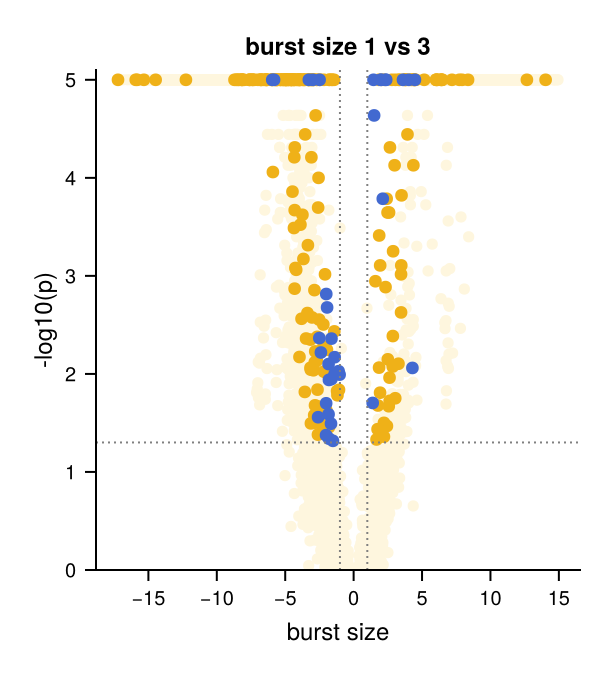

In [44]:
using CairoMakie
fig_bs = volcano_single(
    markers;
    x = :log2FC_bs,
    p = :p_bs,
    deFC = :deTheta_FC_bs,
    deS = :deTheta_and_S_bs,
    xlabel = "burst size",
    title = "burst size $clusa vs $clusb"
)


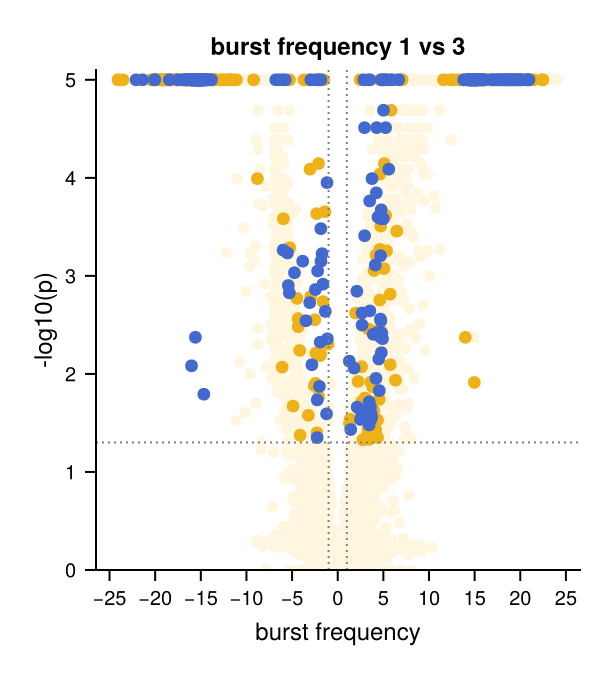

In [45]:
fig_bf = volcano_single(
    markers;
    x = :log2FC_bf,
    p = :p_bf,
    deFC = :deTheta_FC_bf,
    deS = :deTheta_and_S_bs,
    xlabel = "burst frequency",
    title = "burst frequency $clusa vs $clusb"
)

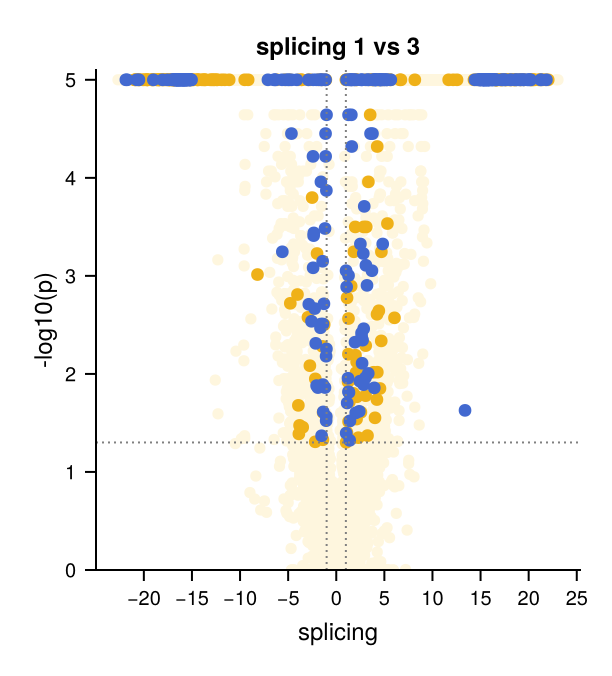

In [46]:
fig_tau = volcano_single(
    markers;
    x = :log2FC_τ,
    p = :p_τ,
    deFC = :deTheta_FC_τ,
    deS = :deTheta_and_S_bs,
    xlabel = "splicing",
    title = "splicing $clusa vs $clusb"
)